## Compare `hg38` vs `hg19` `ENCODE shRNA RNA-Seq` Data

## Purpose: 

Compare the difference between `hg38` and `hg19` `genome builds` for the number of total and differential events along with number of transcripts for "matching pairs".

"Matching pairs" are RBPs that are the same splice type, cell line, and RBP KD. 

For example, `RBFOX2 KD` in `HepG2` `A3SS splice type` is compared between `hg38` and `hg19`. 


In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import os, glob, sys, seaborn
import matplotlib.pyplot as plt

## Literals

In [2]:
cell_lines = ["HepG2", "K562"]
splice_types = ["A3SS", "A5SS", "SE", "MXE", "RI"]

# samples named incorrectly by ENCODE for hg19 data
# this could be because the gene name was different in hg19 genome
hg19_sample_renamings = {
    "EIF2C1": "AGO1",
    "CUGBP1": "CELF1",
    "APOBE": "APOBEC3C",
    "CSDA": "YBX3",
    "RDBP": "NELFE",
    "KIAA1967": "CCAR2",
    "PKM2": "PKM"

}

## Load Data

Get RBPs per cell line that are in common

In [3]:
# key is cell line and value is common RBPs
common_rbps = {}

# for cell line
for cell_line in cell_lines: 
    # get rbp for each hg38 folder 
    # make sure to remove rRNA folders
    hg38_rbps = [folder.split("/")[-1].split("-")[0] for folder in glob.glob("/project/PlatigLab/data/collaborators/BWH/ENCODE_shRNA_RBP_KD/*") if "Transfection" not in folder and cell_line in folder]
    # get unique rbps
    hg38_rbps = set(hg38_rbps)
    
    # get RBP for each hg19 folder
    hg19_rbps = [folder.split("/")[-1].split("-")[0] for folder in glob.glob("/project/PlatigLab/TMP_ENCODE_CORRECTED_P_VALUES/*") if cell_line in folder]
    # make series and replace old hg19 gene names with the updated names
    # convert to set and save 
    hg19_rbps = set(pd.Series(hg19_rbps).replace(hg19_sample_renamings))

    # get intersection of RBPs
    intersected_rbps = sorted(hg38_rbps.intersection(hg19_rbps))
    print(intersected_rbps)
    
    # save 
    common_rbps[cell_line] = intersected_rbps
    

['AARS', 'AATF', 'ABCF1', 'ACO1', 'ADAR', 'AGO1', 'AKAP1', 'AKAP8', 'AKAP8L', 'APOBEC3C', 'ASCC1', 'ATP5C1', 'AUH', 'BCCIP', 'BCLAF1', 'BOP1', 'BUD13', 'CALR', 'CCAR1', 'CCAR2', 'CEBPZ', 'CELF1', 'CIRBP', 'CKAP4', 'CNOT7', 'CPSF6', 'CPSF7', 'CSTF2', 'CSTF2T', 'DAZAP1', 'DDX1', 'DDX19B', 'DDX21', 'DDX24', 'DDX27', 'DDX28', 'DDX3X', 'DDX47', 'DDX5', 'DDX52', 'DDX55', 'DDX59', 'DDX6', 'DHX30', 'DKC1', 'DNAJC2', 'DNAJC21', 'EEF2', 'EFTUD2', 'EIF2S1', 'EIF2S2', 'EIF3D', 'EIF3G', 'EIF4A3', 'EIF4B', 'EIF4G1', 'EIF4G2', 'ESF1', 'ETF1', 'EWSR1', 'EXOSC9', 'FAM120A', 'FASTKD1', 'FASTKD2', 'FIP1L1', 'FKBP4', 'FMR1', 'FTO', 'FUBP3', 'FUS', 'FXR1', 'G3BP1', 'G3BP2', 'GEMIN5', 'GNB2L1', 'GPKOW', 'GRSF1', 'GRWD1', 'GTF2F1', 'HDGF', 'HLTF', 'HNRNPA0', 'HNRNPA1', 'HNRNPA2B1', 'HNRNPAB', 'HNRNPC', 'HNRNPD', 'HNRNPK', 'HNRNPL', 'HNRNPLL', 'HNRNPM', 'HNRNPU', 'HNRNPUL1', 'HSPD1', 'IGF2BP2', 'IGF2BP3', 'ILF2', 'ILF3', 'KHDRBS1', 'KHSRP', 'KIF1C', 'KRR1', 'LARP4', 'LARP7', 'LIN28B', 'LSM11', 'MAGOH', 'MARK2

Save data in dictionary 

In [4]:
# cell line is key and sub-key is RBP and  
# next sub-key is splice type and the sub-keys of that 
# are hg38 or hg19 with values being rMATS tables
rmats_tables = {}

# for cell line 
for cell_line in common_rbps: 
    rmats_tables[cell_line] = {}
    
    cell_line
    
    # for each common rbp in that cell line
    for rbp in common_rbps[cell_line]: 
        
        rmats_tables[cell_line][rbp] = {}
        
        # since hg19 rbp could be different, we need to find out 
        # for now, set as the current name 
        hg19_rbp = rbp
        
        # check if the rbp was called something else in hg19
        for rbp_key in hg19_sample_renamings: 
            # if the hg38 rbp name is found 
            if rbp == hg19_sample_renamings[rbp_key]: 
                # change the hg19_rbp name 
                hg19_rbp = rbp_key
                
        for splice_type in splice_types: 
            rmats_tables[cell_line][rbp][splice_type] = {}
            
            # get hg38 file 
            hg38_file = glob.glob(
                "/project/PlatigLab/data/collaborators/BWH/ENCODE_shRNA_RBP_KD/{}-*{}*/*{}*.txt".format(
                    rbp,
                    cell_line, 
                    splice_type
                )
            )
            
            # remove transfection files
            hg38_file = [file for file in hg38_file if "Transfection" not in file]
            # ake sure only one file 
            assert len(hg38_file)==1, hg38_file
            
            # get hg19 file 
            hg19_file = glob.glob(
                "/project/PlatigLab/TMP_ENCODE_CORRECTED_P_VALUES/{}-*{}*/MATS_output/*{}*yogi*.tsv".format(
                    hg19_rbp,
                    cell_line, 
                    splice_type
                ), 
                recursive=True
            )
            
            # doing this since there are some inconsistently named RBPs 
            if len(hg19_file)!=1: 
                # get hg19 file 
                hg19_file = glob.glob(
                    "/project/PlatigLab/TMP_ENCODE_CORRECTED_P_VALUES/{}-*{}*/MATS_output/*{}*yogi*.tsv".format(
                        rbp,
                        cell_line, 
                        splice_type
                    ), 
                    recursive=True
                )
            
            assert len(hg19_file)==1, hg19_file
            
            # load both dataframes
            rmats_tables[cell_line][rbp][splice_type]["hg38"] = pd.read_csv(hg38_file[0], sep="\t")
            rmats_tables[cell_line][rbp][splice_type]["hg19"] = pd.read_csv(hg19_file[0], sep="\t")
    

'HepG2'

'K562'

## Total Number of Lines

In [5]:
total_df = {}

total_df["Cell Line"] = []
total_df["Difference"] = []
total_df["RBP"] = []

# for each cell line, rbp, and splice type 
for cell_line in rmats_tables: 
    for rbp in rmats_tables[cell_line]: 
        for splice_type in rmats_tables[cell_line][rbp]:
        
            hg19_file = rmats_tables[cell_line][rbp][splice_type]["hg19"] 
            hg38_file = rmats_tables[cell_line][rbp][splice_type]["hg38"]
            
            # append difference in number of events between 
            # hg38 and hg19 file
            total_df["Difference"].append(
                (hg38_file.index.size) - (hg19_file.index.size)
            )
            
            # save cell line and RBP info 
            total_df["Cell Line"].append(cell_line)
            total_df["RBP"].append(rbp)
            
# instantiate dataframe
total_df = pd.DataFrame(total_df)

<Figure size 960x720 with 0 Axes>

<Axes: xlabel='Cell Line', ylabel='Difference'>

Text(0.5, 1.0, 'Each dot represents the difference in the number of events\n between the hg38 and hg19 non-batch corrected files')

Text(-0.2, -100000, 'Positive = larger hg38 file , Negative = larger hg19 file')

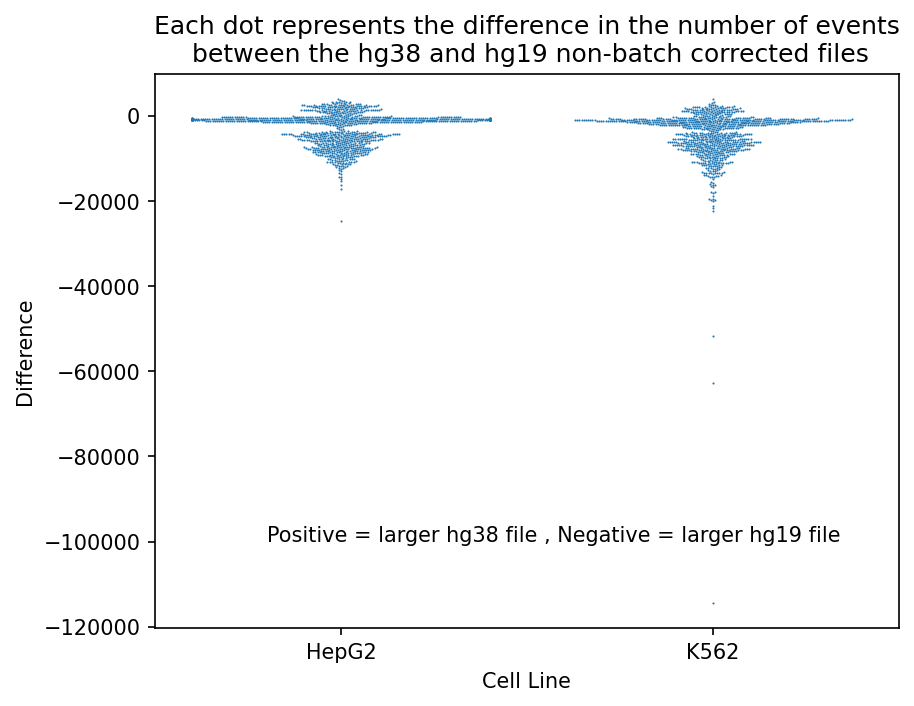

In [6]:
plt.figure(dpi=150)

seaborn.swarmplot(
    data=total_df, 
    y="Difference",
    x="Cell Line",
    size=1
)

plt.title("Each dot represents the difference in the number of events\n between the hg38 and hg19 non-batch corrected files")

plt.text(-0.2, -100000, "Positive = larger hg38 file , Negative = larger hg19 file")

<Figure size 960x720 with 0 Axes>

<Axes: xlabel='Cell Line', ylabel='Difference'>

Text(0.5, 1.0, 'Each dot represents the difference in the number of events\n between the hg38 and hg19 non-batch corrected files\n (subsetted to less than 20K)')

Text(-0.2, -10000, 'Positive = larger hg38 file , Negative = larger hg19 file')

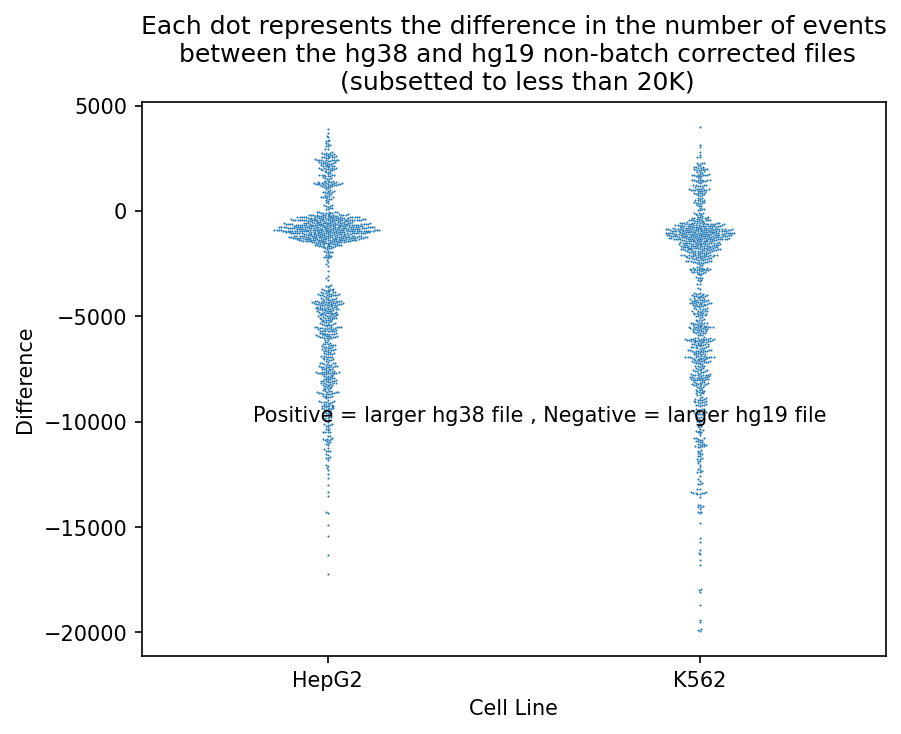

In [7]:
plt.figure(dpi=150)

seaborn.swarmplot(
    data=total_df[abs(total_df["Difference"])<20000], 
    y="Difference",
    x="Cell Line",
    size=1
)

plt.title("Each dot represents the difference in the number of events\n between the hg38 and hg19 non-batch corrected files\n (subsetted to less than 20K)")
plt.text(-0.2, -10000, "Positive = larger hg38 file , Negative = larger hg19 file")

## Difference in Number of Differential Significant Events

In [8]:
difference_df = {}

difference_df["Cell Line"] = []
difference_df["Difference"] = []
difference_df["RBP"] = []
difference_df["Splice Type"] = []

for cell_line in rmats_tables: 
    for rbp in rmats_tables[cell_line]: 
        for splice_type in rmats_tables[cell_line][rbp]:
        
            hg19_file = rmats_tables[cell_line][rbp][splice_type]["hg19"] 
            hg38_file = rmats_tables[cell_line][rbp][splice_type]["hg38"]
            
            # append absolute value of difference in number of events 
            # with FDR <0.1 between matching pairs
            difference_df["Difference"].append(
                (hg38_file[hg38_file["FDR"]<.1].index.size) - (hg19_file[hg19_file["FDR"]<.1].index.size)
            )
            
            # save cell line and RBP and splice type
            difference_df["Cell Line"].append(cell_line)
            difference_df["RBP"].append(rbp)
            difference_df["Splice Type"].append(splice_type)
            
difference_df = pd.DataFrame(difference_df)

<Figure size 960x720 with 0 Axes>

/home/jve4pt/.local/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 38.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/jve4pt/.local/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 29.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Cell Line', ylabel='Difference'>

Text(0.5, 1.0, 'Each dot represents the difference in the number of FDR < 0.1 events\n between the hg38 and hg19 non-batch corrected files')

Text(-0.2, -10000, 'Positive = larger hg38 file , Negative = larger hg19 file')

/home/jve4pt/.local/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 58.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/jve4pt/.local/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 52.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


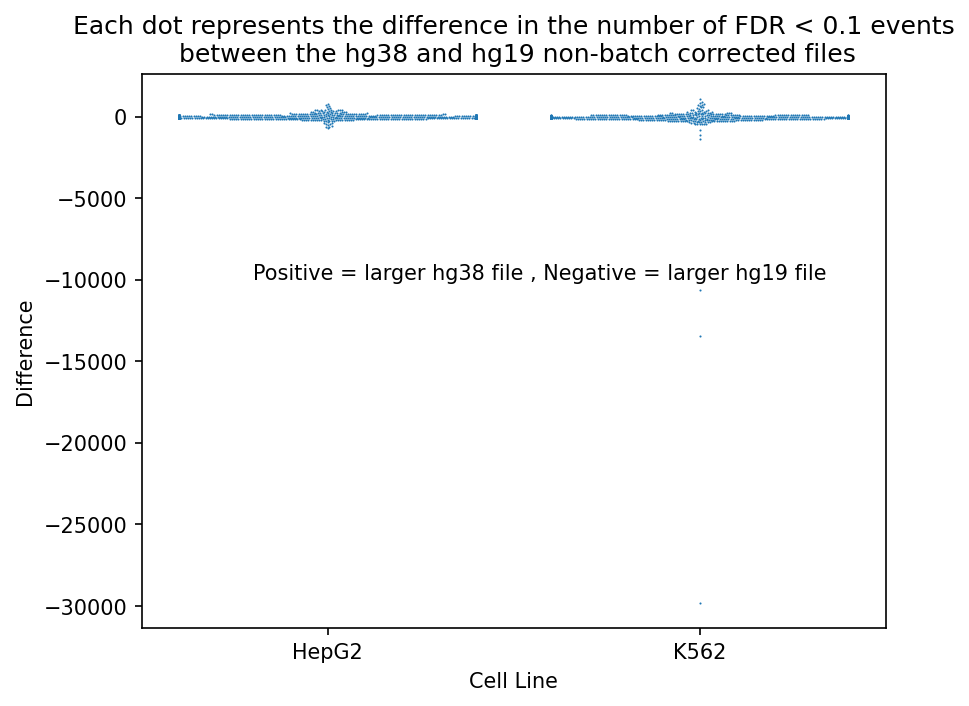

In [9]:
plt.figure(dpi=150)

seaborn.swarmplot(
    data=difference_df, 
    y="Difference",
    x="Cell Line",
    size=1
)

plt.title("Each dot represents the difference in the number of FDR < 0.1 events\n between the hg38 and hg19 non-batch corrected files")

plt.text(-0.2, -10000, "Positive = larger hg38 file , Negative = larger hg19 file")

<Figure size 960x720 with 0 Axes>

<Axes: xlabel='Cell Line', ylabel='Difference'>

Text(0.5, 1.0, 'Each dot represents the difference in the number of FDR < 0.1 events\n between the hg38 and hg19 non-batch corrected files\n (subsetted to < 1000)')

Text(-0.2, 500, 'Positive = larger hg38 file , Negative = larger hg19 file')

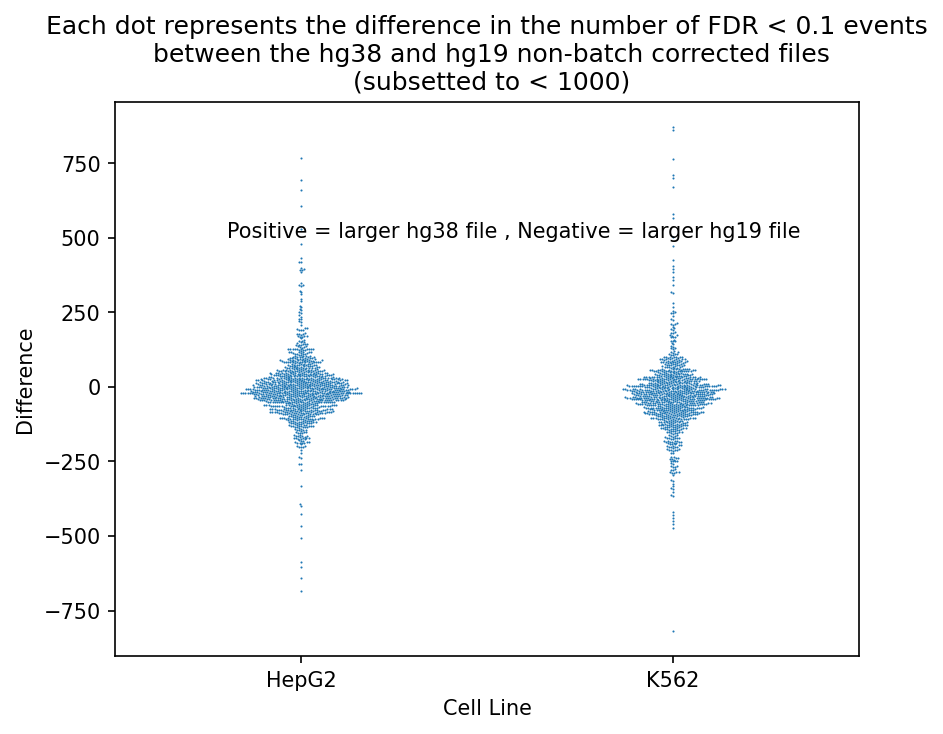

In [10]:
plt.figure(dpi=150)

seaborn.swarmplot(
    data=difference_df[abs(difference_df["Difference"])<1000], 
    y="Difference",
    x="Cell Line",
    size=1
)

plt.title("Each dot represents the difference in the number of FDR < 0.1 events\n between the hg38 and hg19 non-batch corrected files\n (subsetted to < 1000)")

plt.text(-0.2, 500, "Positive = larger hg38 file , Negative = larger hg19 file")

## Difference in Number of Genes Profiled

In [11]:
transcript_df = {}

transcript_df["Cell Line"] = []
transcript_df["Difference"] = []
transcript_df["RBP"] = []

for cell_line in rmats_tables: 
    for rbp in rmats_tables[cell_line]: 
        for splice_type in rmats_tables[cell_line][rbp]:
        
            hg19_file = rmats_tables[cell_line][rbp][splice_type]["hg19"] 
            hg38_file = rmats_tables[cell_line][rbp][splice_type]["hg38"]
            
            # append absolute value of difference in number of genes profiled
            transcript_df["Difference"].append(
                (hg38_file["geneSymbol"].unique().size) - (hg19_file["geneSymbol"].unique().size)
            )
            
            # save cell line and RBP 
            transcript_df["Cell Line"].append(cell_line)
            transcript_df["RBP"].append(rbp)
            
transcript_df = pd.DataFrame(transcript_df)

<Figure size 960x720 with 0 Axes>

<Axes: xlabel='Cell Line', ylabel='Difference'>

Text(0.5, 1.0, 'Each dot represents the difference in the number transcripts\n between the hg38 and hg19 non-batch corrected files')

Text(-0.2, -1000, 'Positive = larger hg38 file , Negative = larger hg19 file')

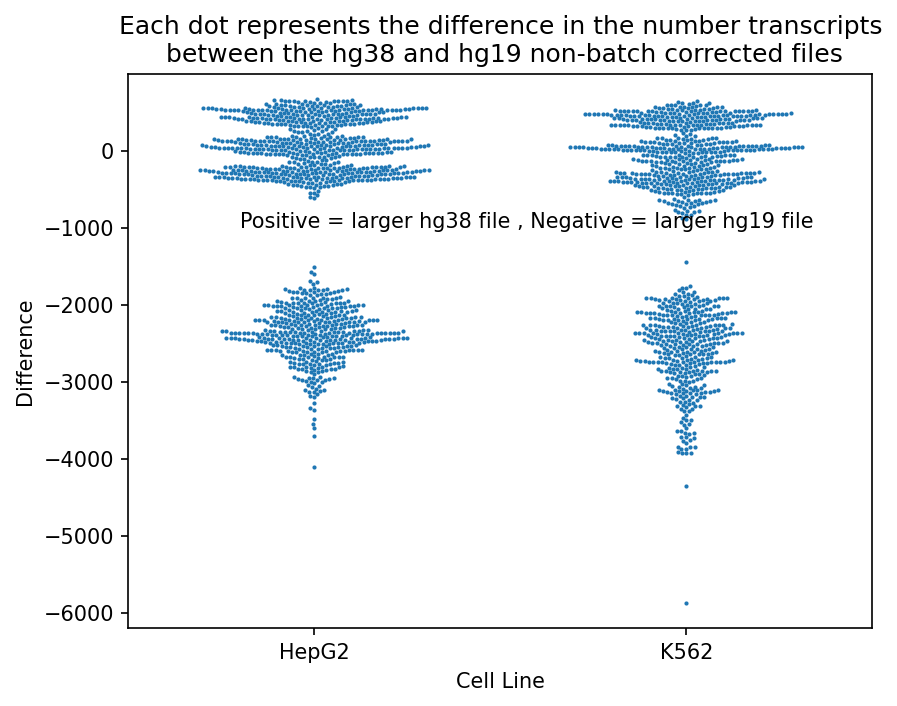

In [12]:
plt.figure(dpi=150)

seaborn.swarmplot(
    data=transcript_df, 
    y="Difference",
    x="Cell Line",
    size=2
)

plt.title("Each dot represents the difference in the number transcripts\n between the hg38 and hg19 non-batch corrected files")

plt.text(-0.2, -1000, "Positive = larger hg38 file , Negative = larger hg19 file")

## Scatter Plot of Number of Differential Events vs. Number of Unique Genes in `rMATS` File

In [13]:
ratio_difference_df = {}

ratio_difference_df["Cell Line"] = []
ratio_difference_df["RBP"] = []
ratio_difference_df["Difference"] = []
ratio_difference_df["Splice Type"] = []

for cell_line in rmats_tables:     
    for rbp in rmats_tables[cell_line]: 
        for splice_type in rmats_tables[cell_line][rbp]:
        
            hg19_file = rmats_tables[cell_line][rbp][splice_type]["hg19"] 
            hg38_file = rmats_tables[cell_line][rbp][splice_type]["hg38"]
            
            # take the ratio of significant events divided by 
            # number of unique genes profiled for both hg19 and hg38
            # take the difference of these ratios 
            ratio_difference_df["Difference"].append(
                (
                    (hg38_file[hg38_file["FDR"]<0.1].index.size) / (hg38_file["geneSymbol"].unique().size)
                )
                -
                (    
                    (hg19_file[hg19_file["FDR"]<0.1].index.size) / (hg19_file["geneSymbol"].unique().size)
                )
            )
            
            # save cell line and RBP and splice type
            ratio_difference_df["Cell Line"].append(cell_line)
            ratio_difference_df["RBP"].append(rbp)
            ratio_difference_df["Splice Type"].append(splice_type)
    
ratio_difference_df = pd.DataFrame(ratio_difference_df)

<Figure size 960x720 with 0 Axes>

/home/jve4pt/.local/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


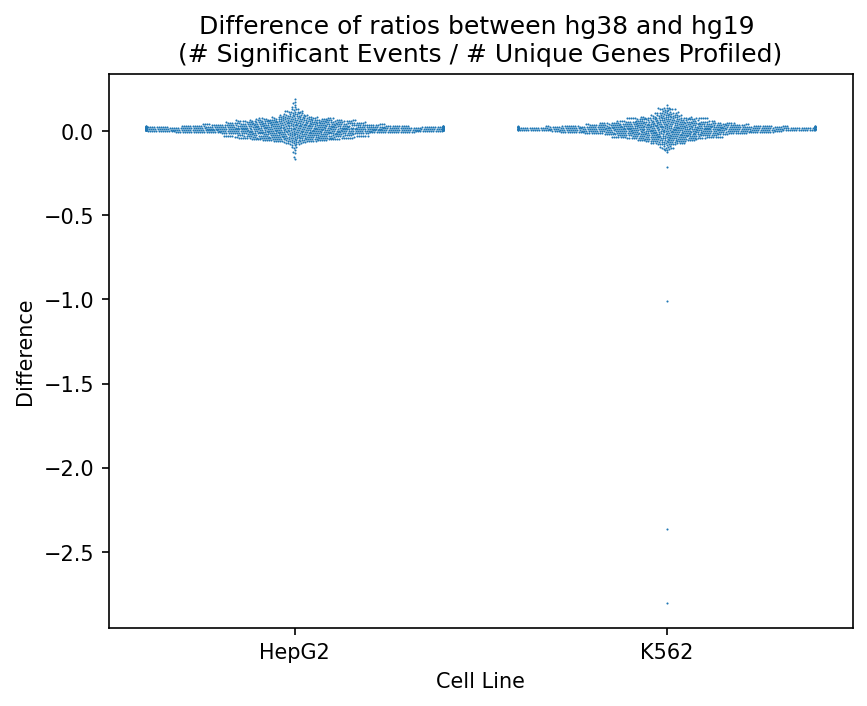

In [14]:
plt.figure(dpi=150)


_=seaborn.swarmplot(
    ratio_difference_df, 
    x="Cell Line", 
    y="Difference", 
    size=1
)

_=plt.title(
    "Difference of ratios between hg38 and hg19 \n(# Significant Events / # Unique Genes Profiled)".format(cell_line)
)

plt.show()

<Figure size 960x720 with 0 Axes>

(-0.5, 0.5)

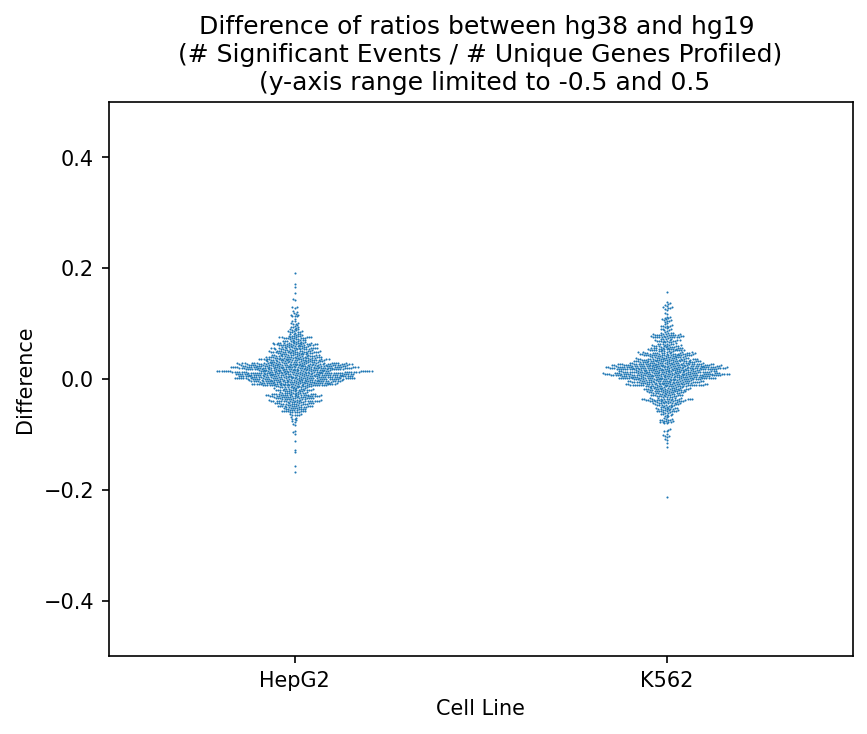

In [15]:
plt.figure(dpi=150)


_=seaborn.swarmplot(
    ratio_difference_df, 
    x="Cell Line", 
    y="Difference", 
    size=1
)

plt.ylim(-0.5, 0.5)

_=plt.title(
    "Difference of ratios between hg38 and hg19 \n(# Significant Events / # Unique Genes Profiled)\n (y-axis range limited to -0.5 and 0.5".format(cell_line)
)

plt.show()